<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/Arbol_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Impotarción de librerias
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
#Cargar el conjunto de datos
#Datos de ejemplo
data ={
    'Cielo': ['Soleado', 'Soleado', 'Nublado', 'Lluvioso', 'Lluvioso', 'Lluvioso', 'Nublado',
              'Soleado', 'Soleado', 'Lluvioso', 'Soleado', 'Nublado', 'Nublado', 'Lluvioso'],
    'Humedad': ['Alta', 'Alta', 'Alta', 'Normal', 'Normal', 'Alta', 'Normal',
                'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Alta'],
    'Viento': ['Débil', 'Fuerte', 'Débil', 'Débil', 'Fuerte', 'Débil', 'Fuerte',
               'Débil', 'Débil', 'Débil', 'Fuerte', 'Fuerte', 'Débil', 'Fuerte'],
    'Jugar': ['No', 'No', 'Sí', 'Sí', 'No', 'Sí', 'Sí',
              'No', 'Sí', 'Sí', 'Sí', 'Sí', 'Si', 'No']
}

In [3]:
#Convertir a dataframe de pandas
df = pd.DataFrame(data)
print("Dataset Original:")
print(df)

Dataset Original:
       Cielo Humedad  Viento Jugar
0    Soleado    Alta   Débil    No
1    Soleado    Alta  Fuerte    No
2    Nublado    Alta   Débil    Sí
3   Lluvioso  Normal   Débil    Sí
4   Lluvioso  Normal  Fuerte    No
5   Lluvioso    Alta   Débil    Sí
6    Nublado  Normal  Fuerte    Sí
7    Soleado    Alta   Débil    No
8    Soleado  Normal   Débil    Sí
9   Lluvioso  Normal   Débil    Sí
10   Soleado  Normal  Fuerte    Sí
11   Nublado    Alta  Fuerte    Sí
12   Nublado  Normal   Débil    Si
13  Lluvioso    Alta  Fuerte    No


In [4]:
#Preprocesar los datos
#Los algoritmos requieren valores numericos, no strings. Usamos codificacion de etiquetas:
#Convertir variables categoricas a numericas
from sklearn.preprocessing import LabelEncoder

#Crear un codificador para cada columna
label_encoders = {}
df_encoded = df.copy() #Copia del dataframe original

for column in df.columns:
    le = LabelEncoder() #Crear un codificador de etiquetas
    df_encoded[column] = le.fit_transform(df[column]) #Aplicar el codificador a la columna
    label_encoders[column] = le #Guardar los codificadores para interpretar despues

print("\nDataset codificado:")
print(df_encoded)


Dataset codificado:
    Cielo  Humedad  Viento  Jugar
0       2        0       0      0
1       2        0       1      0
2       1        0       0      2
3       0        1       0      2
4       0        1       1      0
5       0        0       0      2
6       1        1       1      2
7       2        0       0      0
8       2        1       0      2
9       0        1       0      2
10      2        1       1      2
11      1        0       1      2
12      1        1       0      1
13      0        0       1      0


In [5]:
#Dividir datos en Entrenamiento y Prueba
#Separar caracteristicas (x) y variable objetivo (y)
# x son las caracteristicas (Cielo, Humedad, Viento) y y es la variable objetivo (Jugar) (drop es eliminar la columna 'Jugar')
x = df_encoded.drop('Jugar', axis=1) #Todas las columnas excepto 'Jugar' axis se refiere a las columnas
#y se refiere a la variable objetivo, que es 'Jugar'
y = df_encoded['Jugar'] # Solo la columna 'Jugar'

#Dividimos en 70% entrenamiento, 30% en prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print("\n Datos de entrenamiento:")
print(x_train.head())
print("\n Datos de prueba")
print(x_test.head())


 Datos de entrenamiento:
    Cielo  Humedad  Viento
8       2        1       0
2       1        0       0
1       2        0       1
13      0        0       1
4       0        1       1

 Datos de prueba
    Cielo  Humedad  Viento
9       0        1       0
11      1        0       1
0       2        0       0
12      1        1       0
5       0        0       0


In [6]:
#Entrenar el arbol de decision
# Crear y enternar el modelo
model = DecisionTreeClassifier(
    criterion='gini', #Metrica para dividir nodos (Gini o Entropia)
    max_depth=3, #Profundidad Maxima del arbol (evita overfitting) 3 porque es un arbol pequeno
    random_state=42
)

model.fit(x_train, y_train)

#Predecir en los datos de prueba
y_pred = model.predict(x_test)

#Calcular precision
accuracy = accuracy_score(y_test, y_pred) #accuracy_score calcula la precision del modelo comparando las prediciones con los valores reales
print(f"Precisión del modelo: {accuracy:.2f}")

Precisión del modelo: 0.60


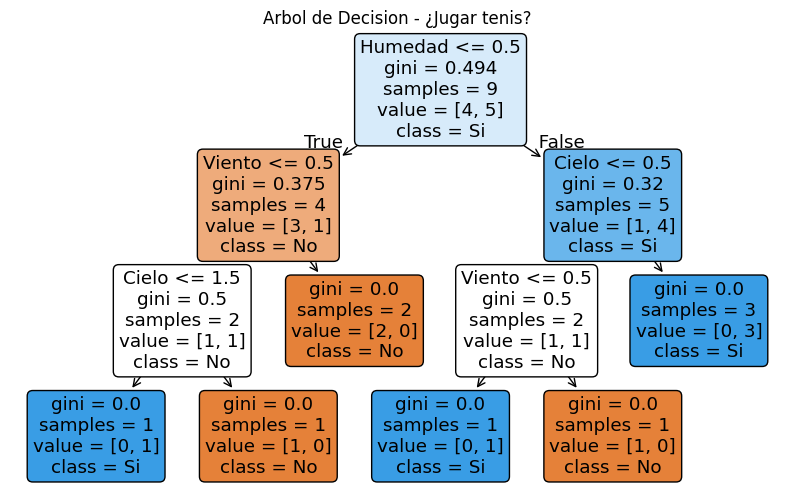

In [7]:
#Visualizar el arbol
#Configurar figura
plt.figure(figsize=(10, 6))

#Dibujar el arbol
#plot_tree es una funcion de sklearn que dibuja el arbol de decision
#model es el arbol de decision entrenado
#feature_names son los nombres de las caracteristicas (Cielo, Humedad, Viento)
#Class_names son los nombres de las clases (Jugar=0 > 'No' > Jugar=1 > 'Si')

plot_tree(
    model,
    feature_names=x.columns, #Nombres de las caracteristicas
    class_names=['No', 'Si'], #Nombres de las clases (Jugar=0 > 'No')
    filled=True, #Colorear por clase
    rounded=True, #Forma de los nodos
    impurity= True, #Mostrar impureza (Gini)
)

plt.title("Arbol de Decision - ¿Jugar tenis?")
plt.show()